### Lifestyle data, dataset evaluation report

**NOTE:** This report could still be improved by adding more analysis on the importance of variables.

**TODO: improve this report, remove unnecessary visualizations and analysis parts**

___

## General information

Target variable is **Rating** (ordinal, classification).

**Rating** has a range of 1-5. 

5 implies the best rating.

This dataset has a considerable amount of nominal categories.

### Variables to drop or to process further

- **ParticipantID** can be dropped (no significance in this context, just an identifier field)


PhysicalActivities and CommunityInvolvement, missing approximately 20% of data, but since total data is ~500 rows, probably try to fix with average values to fill in the gaps. 

There are no duplicate rows in the dataset.

### Rest of the variables

- Age
- Location
- DietType
- LocalFoodFrequency
- TransportationMode
- EnergySource
- HomeType
- HomeSize
- ClothingFrequency
- SustainableBrands
- EnvironmentalAwareness
- CommunityInvolvement
- MonthlyElectricityConsumption
- MonthlyWaterConsumption
- Gender
- UsingPlasticProducts
- DisposalMethods
- PhysicalActivities

## Variable importance and redundancy analysis

**Rating** is highly correlated with DietType, EnergySource and SustainableBrands (ydata alerts). However, some other variables correlate heavily also with Rating, like electricity and water consumption correlating negatively (over -0.5 each).

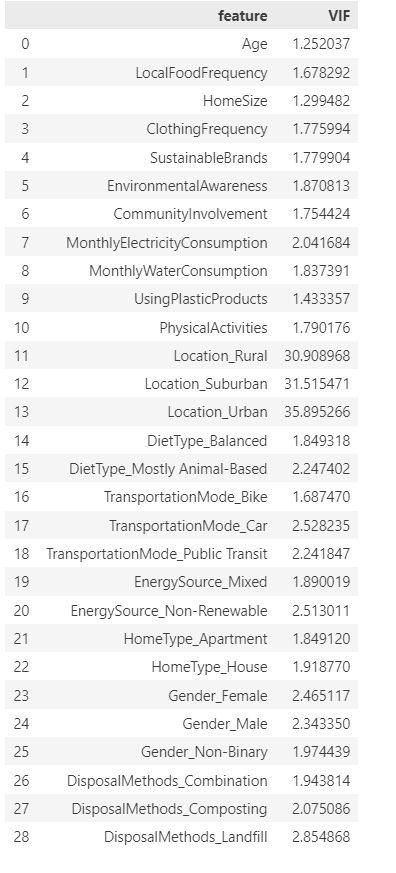

All the location variables are fairly high here, implying we can drop two of them (probably a binary variable => urban or not). The other variables seem OK from VIF -point of vie, so surprisingly little redundancy going on so far.

**Let's study SelectKBest next!**

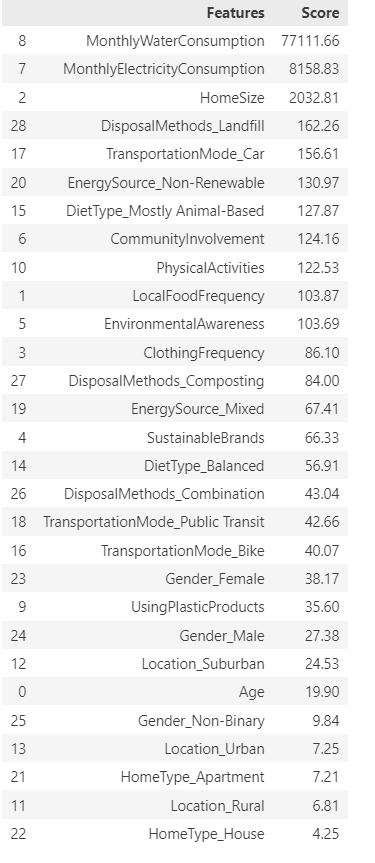

Water and Electricity consumptions are highly marked here. HomeSize is also surprisingly large. All the categorical variables are very low, which might imply SelectKBest is not very suitable for detecting connections in encoded categoricals. SHAP/LIME might be more beneficial here.

Let's study **Fisher's score** as well.

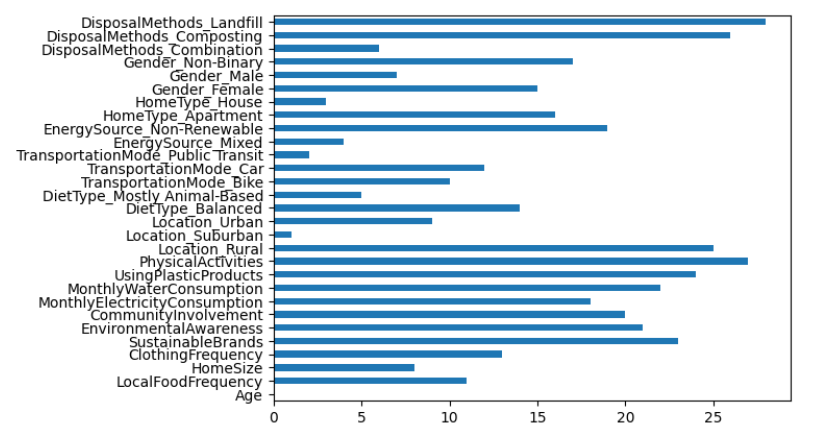

Fisher score seems to emphasize categoricals quite nicely. Weirdly Age doesn't really matter much. The location seems to show importance mostly in rural setting. Therefore, using a binary variable for location might be a viable option.

Many of the three-level categoricals seem like they would benefit from simplification to a binary variable (HomeType Other is nowhere to be seen in any of the feature ranking tools.)

## Distributions and imbalances

Support variables are fairly well balanced (minus the Gender -variable).

However, the target variable Rating has a considerable imbalance, where best rating 5 is overrepresented, and rating 2 is underrepresented. Since this is a classification dataset, a uniform distribution is most likely the most optimal one (even distribution across all options).

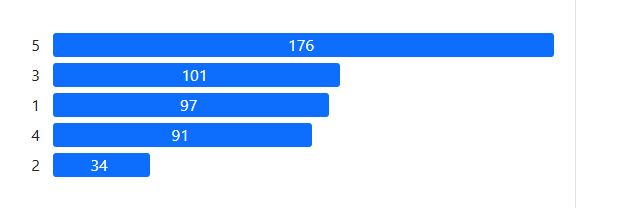

Gender-variable has slight imbalance, but not as severe as the Rating:

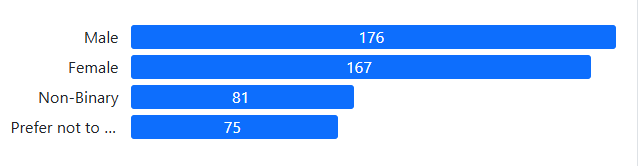

Even though the Age is not perfectly balanced in distribution, it still has a nice representation for all age groups, except in the very high end. Try to group age-ranges if needed later (20-25, 25-30 etc.)

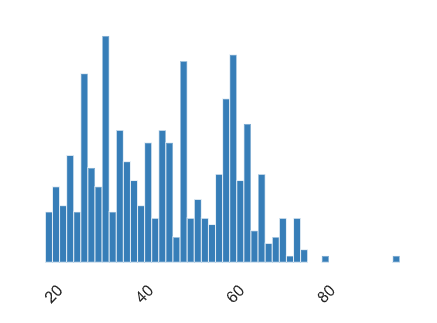

HomeSize is also quite balanced, even in the low and high ends, with some smaller gaps in the between. Keep this in mind, when optimizing distributions and outliers.

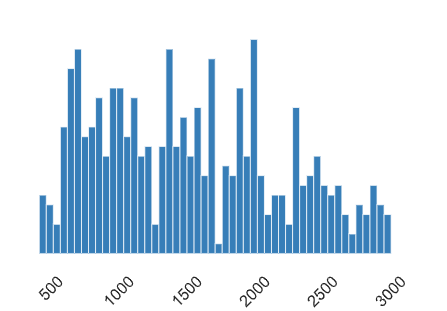

Electricity consumption is closer to balanced than normal distribution, which can be fine, but let's keep in mind that this is a potential aspect for optimization. Same applies to water consumption.

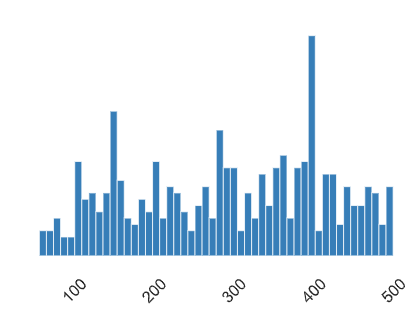

Water consumption distribution is fairly similar to electricity.

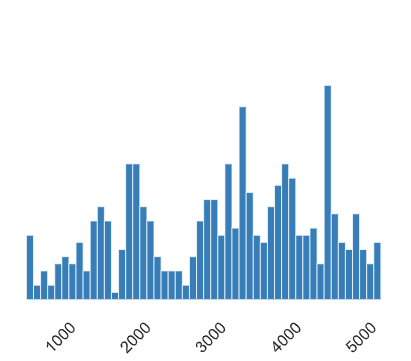

## Imbalanced categorical combinations

We used **apriori** to analyze the dataset for potentially rare combinations of variables.

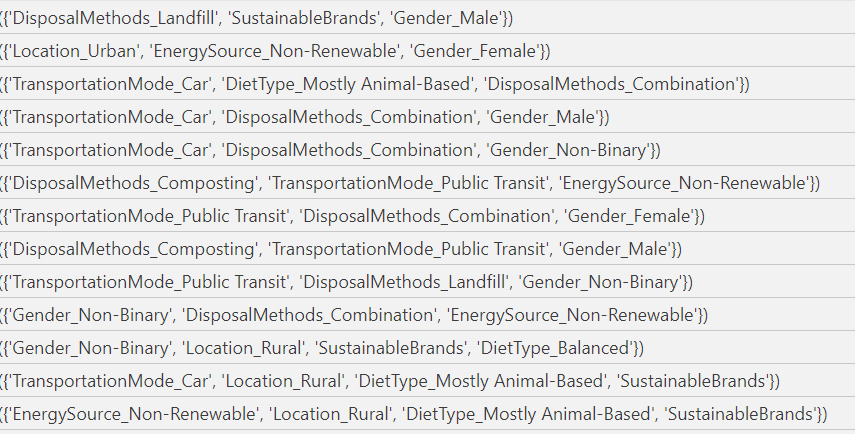

Since this dataset is fairly polarized due to its topic (sustainability), we see some combinations that do not have any samples in the dataset (the dataset is also small, 500-600 rows only).

For example, there are no samples with Landfill, SustainableBrands and Male in the dataset. Same applies to Urban, Non-renewable and Female. In total, there were over 2000 combinations found where no data was found, however, most of the later combinations are vast combinations of more than 4 categories.

However, this still implies a problem. Even though there are combinations that never likely happen, our model will still struggle if non-existing combinations are present in our training and testing data.

One idea would be to use CatBoost as the machine learning algorithm, since it specializes in handling a vast amount of categories in a dataset.

The best option would to have more data with more diverse combinations.

Also, to analyze which missing combinations are crucial from practical point of view (combinations that SHOULD be in the dataset, but are not), would be a good further analysis point.

## Irregularities in trends / contradictions

**NOTE: this part could be heavily expanded by studying other variables too**.

**ALSO: this part is a bit complex due to the sheer number of categoricals, making analysis quite difficult.**

### ALSO: doing overlap detection purely on categorical variables is quite difficult, it's easier to find them in continuous variables (see the red wine dataset analysis for this!)

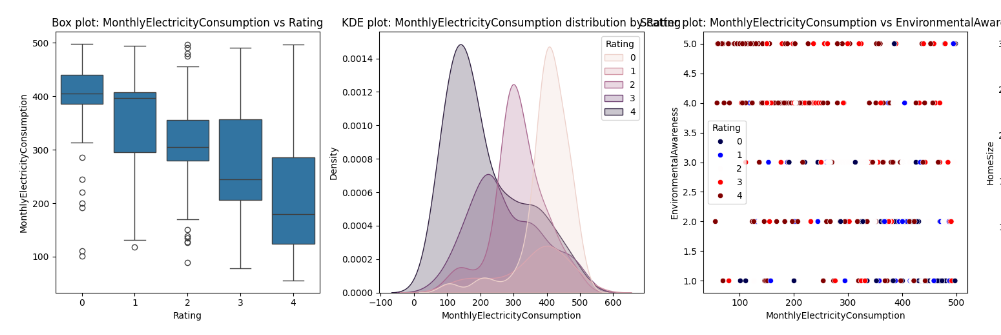

We can roughly see how electricity consumption goes down as rating goes up. However, when comparing environmental awareness to electricity consumption, there's a very mild separation between them. In other words, high electricity consumption with low environmental awareness, seems to have an effect towards lower rating.

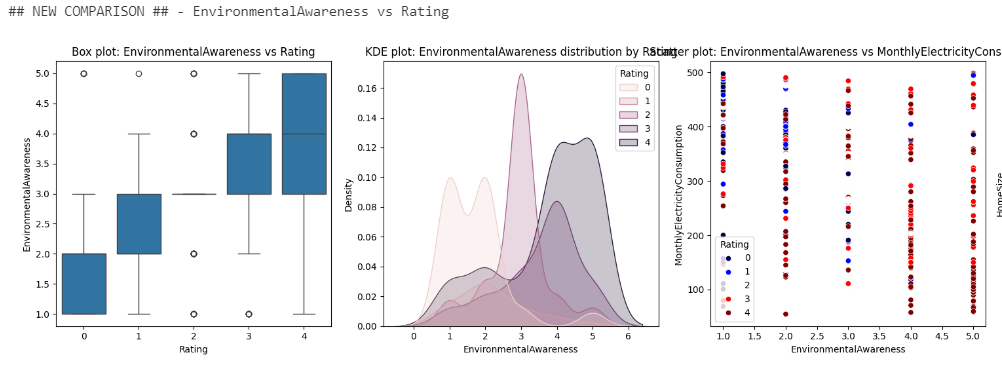

Rating seems to go up as environmental awareness goes up. There's a slight division where high environmental awareness usually results in high rating, but some exceptions do exist. Low ratings are often connected to lower environmental awareness. There's overlap, but due to small dataset, it can't be seen very clearly.

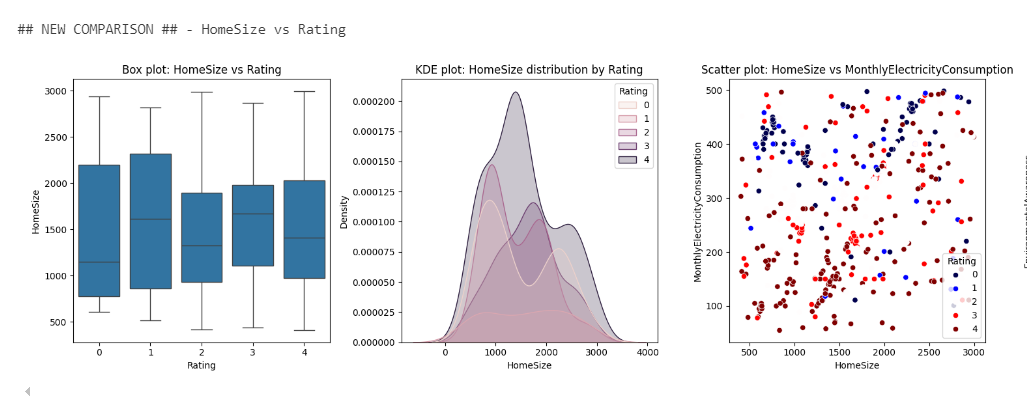

There's some division between the rating based on age vs electricity consumption. Some overlapping can be seen. Age vs environmental awareness also seems a bit noisy in ratings of 3 and less.

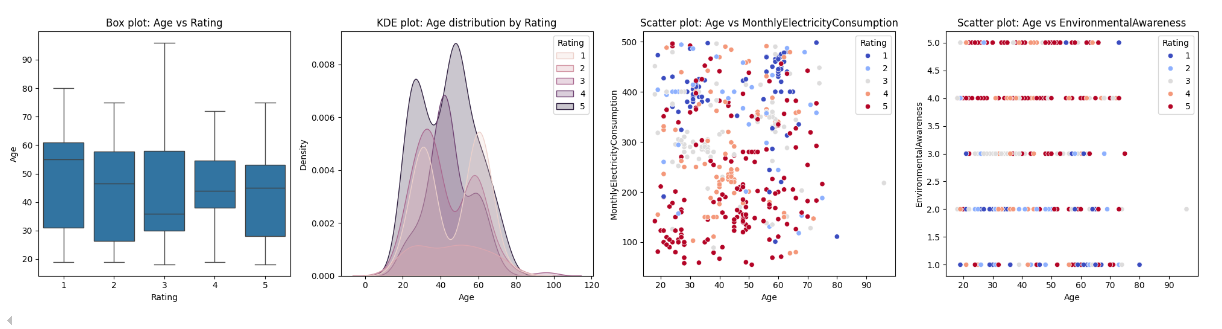

HomeSize seems to be all over the place when it comes to rating. Low rating is often combined with high electricity consumption and large home. However, there are large homes too in the high rating. This is quite noisy, but could be also considered as some level of overlapping.

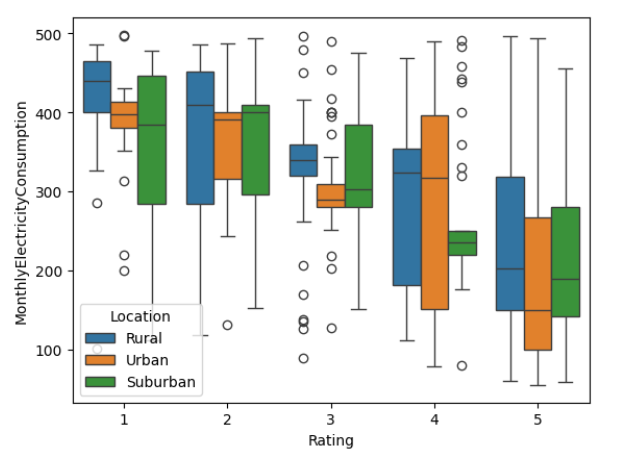

There's seems to be a rought trend on electricity consumption and rating, regardless of location. However, lots of outliers/noise going on.

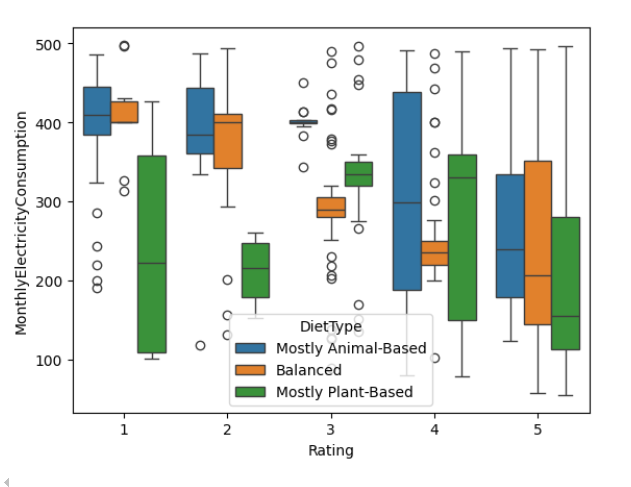

This is all over the place... there's no rough trend in sight, all diet types are present in all ratings when compared to electricity consumption.

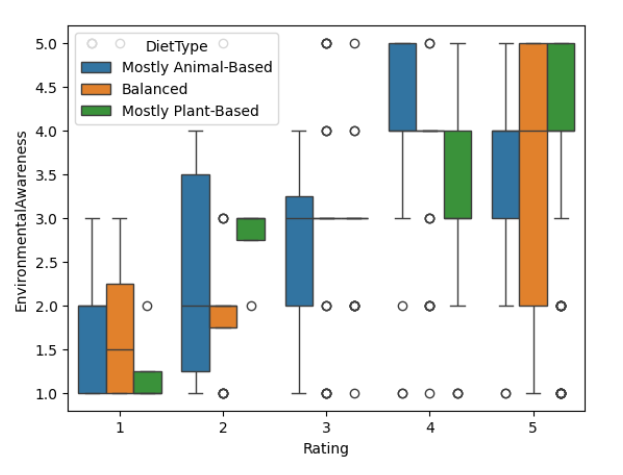

There's more trend seen here, but it seems diet type is quite messy regarding the target.

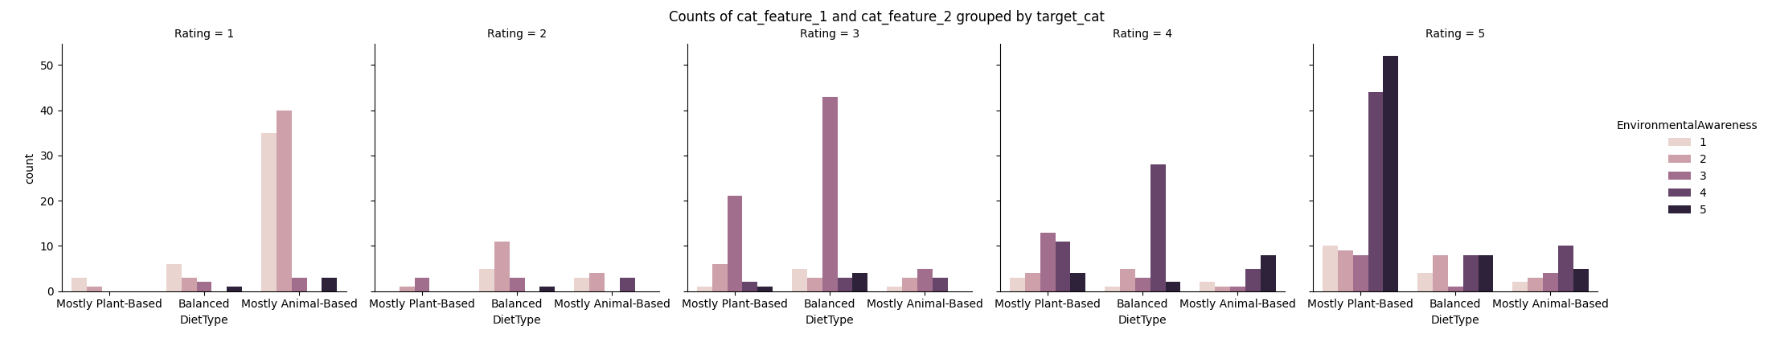

Roughly we can see that low environmental awareness stacks in worst rating, and we can also see a rough distribution of animal based diets being in the lower ratings. Mostly plant-based diets  are in the top rating, but all diet types are scattered across ratings. Seems like diet type is a messy variable, causing difficulties in the dataset regarding the Rating.

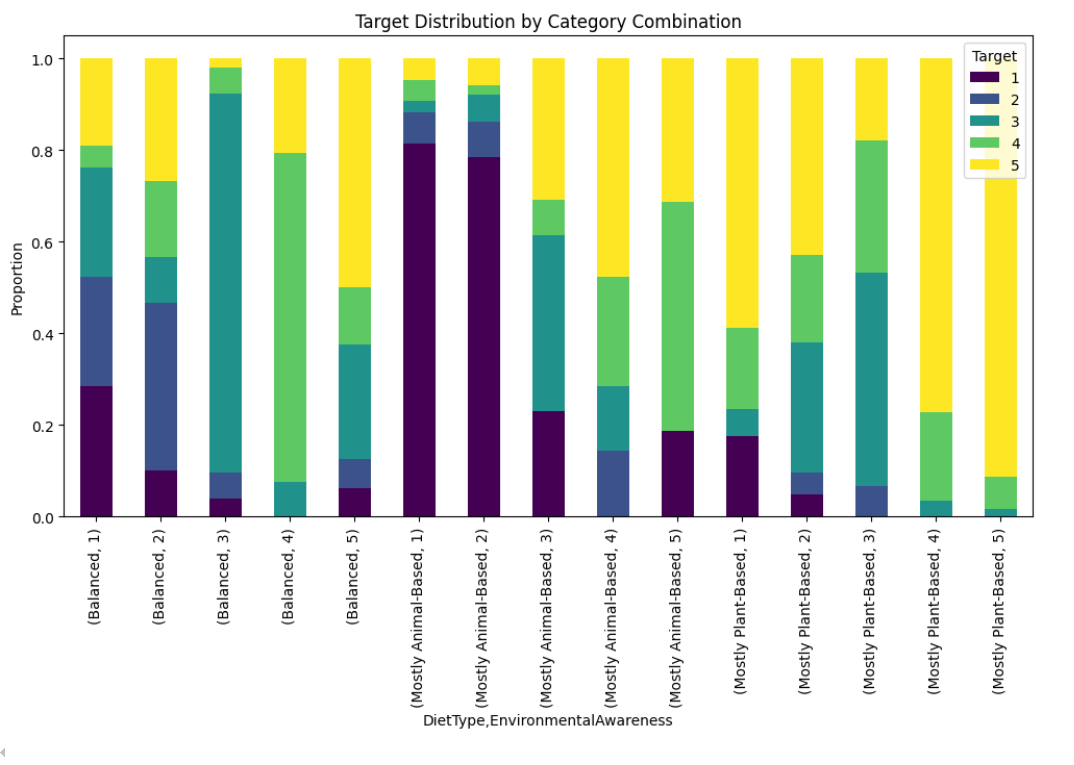

Roughly we can see the logic here, animal based diets with low environmental awareness dominate ratings 1 and 2, balanced diet with average environmental awareness dominate the rating 3, and high environmental awareness with mostly plant based diets dominate ratings 4 and 5.

**Summary:** Overlapping is difficult to assess due to the small dataset, everything seems just noisy at best. We can see some trends, but pretty much everything has exceptions which normally would mean high overlap, but I believe there's not enough data to make that assumption. The dataset seems quite much "all over the place".

## Noise / outliers

Noise and outlier detection in this dataset is difficult due to the vast amount of categorical variables and also the small amount of data (500-600 samples only). Most likely we lose crucial data even with the slightest noise/outlier removal in this case.

Because of this, MAD + Isolation Forest are most likely sufficient unless we get more data, with mild configurations.

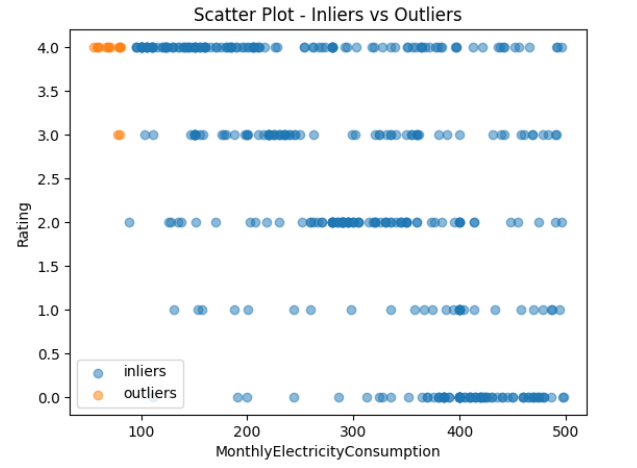

We can see a little bit of noise in the higher ratings (4 and 5) regarding the MonthlyElectricityConsumption.

MAD is a bit difficult to use with classification, it's usually helpful only in continuous variables.

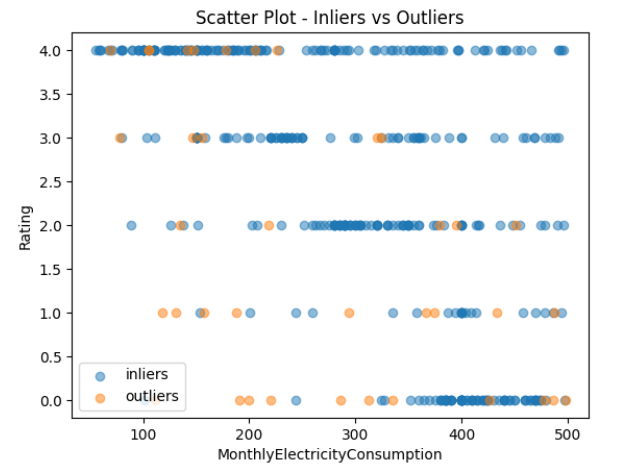

For Isolation Forest, we can see a bit more complex recognition of outliers within the dataset as well.

PCA clustering (principal component) analysis could be helpful here also determining noise in the dataset.

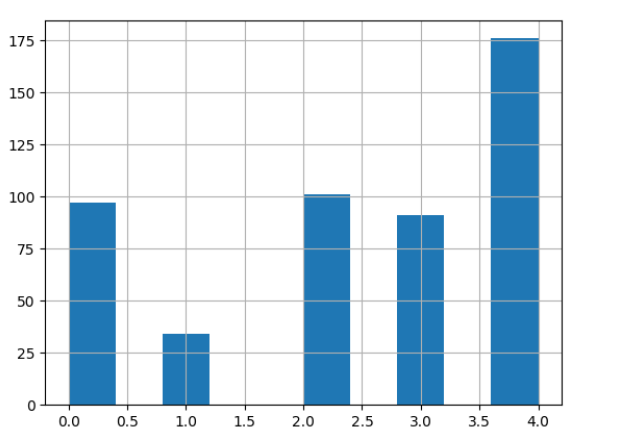

## SHAP / LIME

Below we can see the SHAP result for our multitarget classification. 

We can roughly see how EnvironmentalAwareness, Age, Electricity and Water consuumption, CommunityInvolvement and animal-based diet affect largely the model's predictions. 

We could probably fix a few of the problems raised in the apriori result by attempting to remove some of the more less-impactful features in the bottom of this list. 

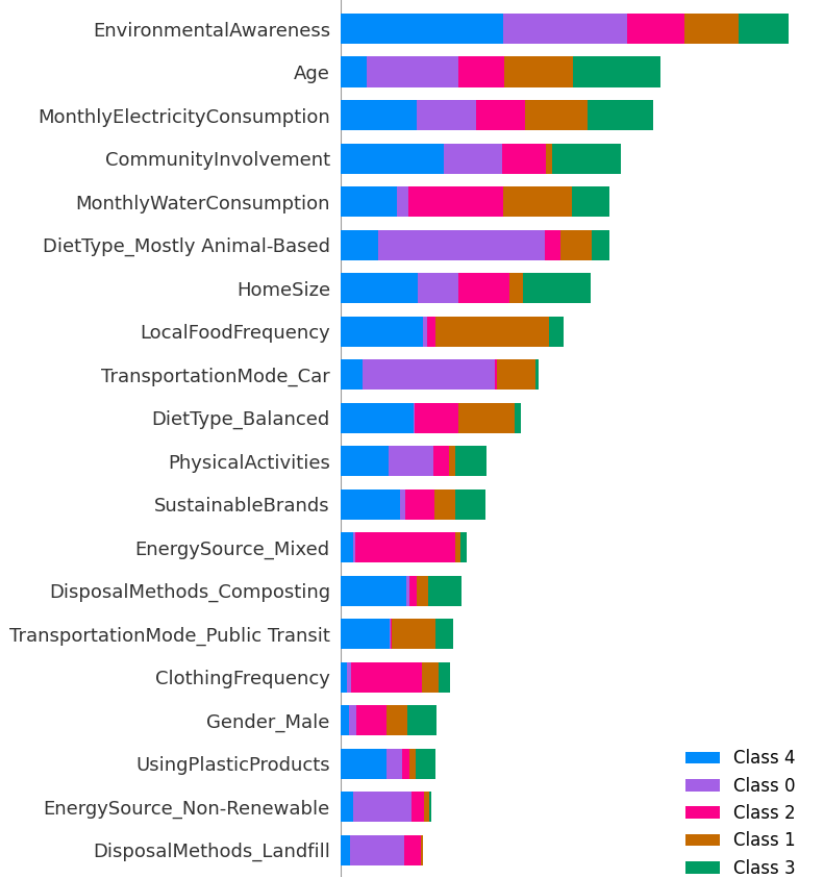

SHAP result for Rating 0. We can see how animal-based diet and using a car increases the likelihood of having a rating of 0. Also being less environmental aware increases the likelihood of Rating 0.The rest of the variables still seem to have a surprisingly large effect on rating 0 here.

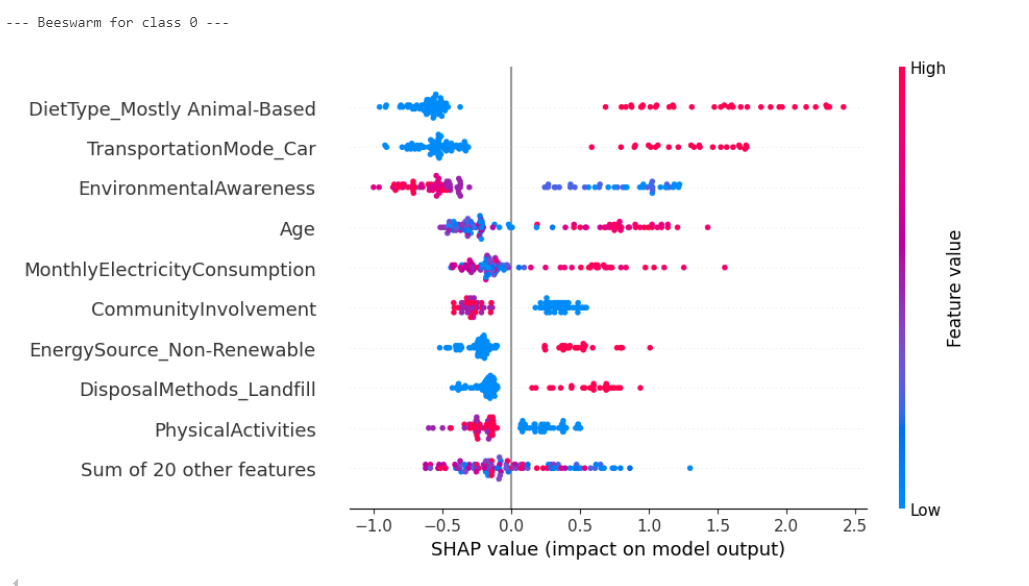

Best rating seems to be affected by high environmental awareness, high community involvement, high local food frequency. HomeSize seems to a bit more unclear, but generally a bigger home seems to also increase the rating, which is a bit contradictory. Less water and electricity seems to improve best rating too.

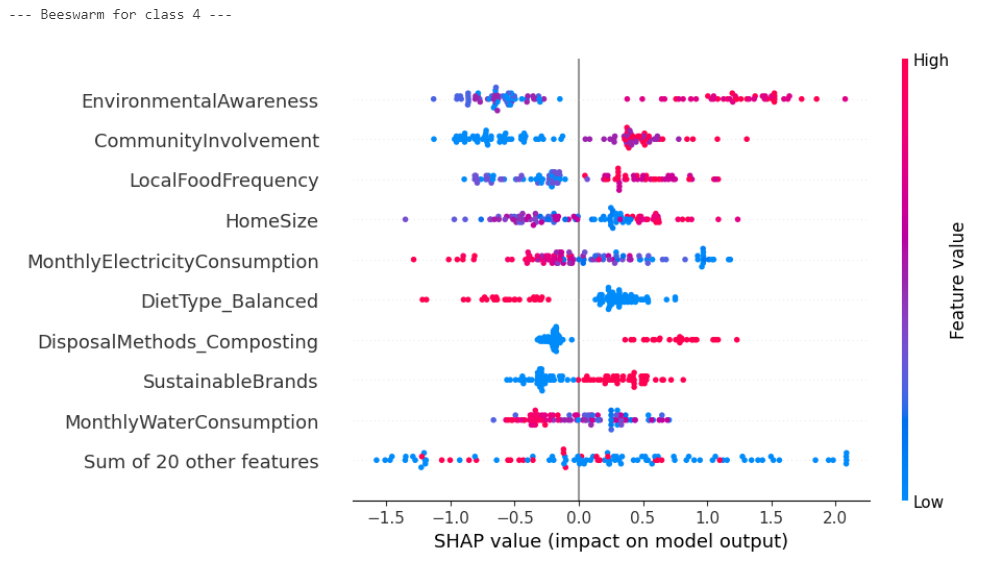

Diet Type fares surprisingly well in SHAP, clearly providing information between the extreme ratings. This can be due to using binary variables in this stage instead of the original nominal categories. (mostly animal based diet => yes/no)

**NOTE: studying the three other ratings could be beneficial as well, to see if they follow the same trends as the extreme ratings.**

We can also see how the water and electricity consumption affect the rating. As water and electricity consumptions rise => rating goes down rapidly. 

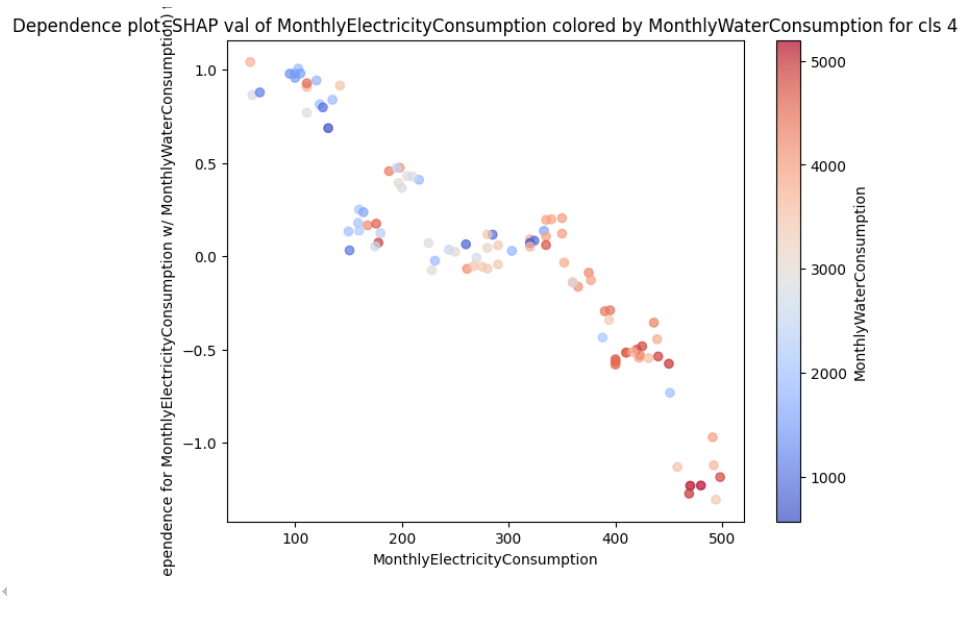

Since water and electricity consumption are tightly related, there might some redundancy in one of them (water consumption can probably be dropped).

The variables not shown in the worst and best rating can considered as options for removal in order to reduce amount of variables in this dataset.

LIME is not very clear in this case, due to small value ranges in the dataset. Here we can still see the effect of environemntal awareness, diet type, transportation mode and local food frequency + electricity consumption. Mostly same things as in SHAP. (this example is for best rating)

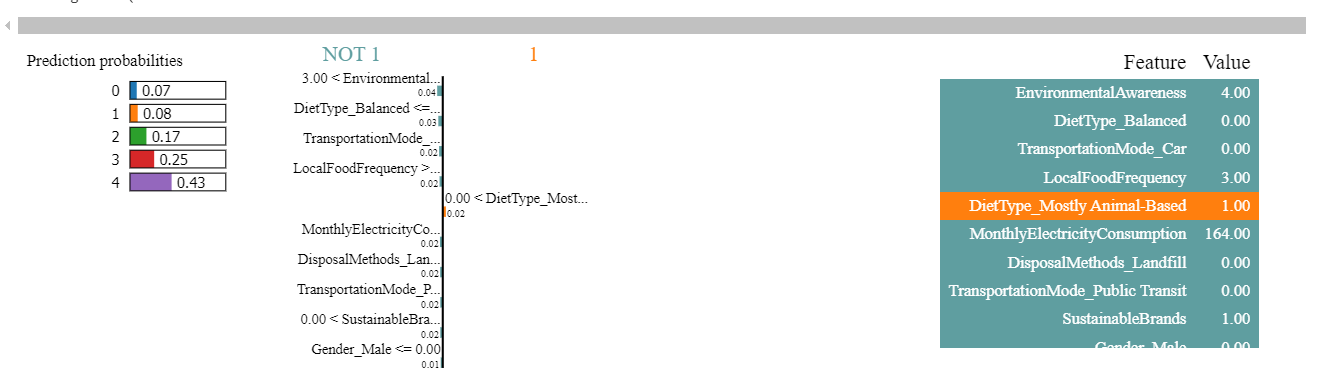

Here's the LIME version for the worst rating, pretty much same results as in SHAP. However in this situation, we can't see mostly animal based diet anywhere (probably an exception in the data, LIME only studies one row at a time):

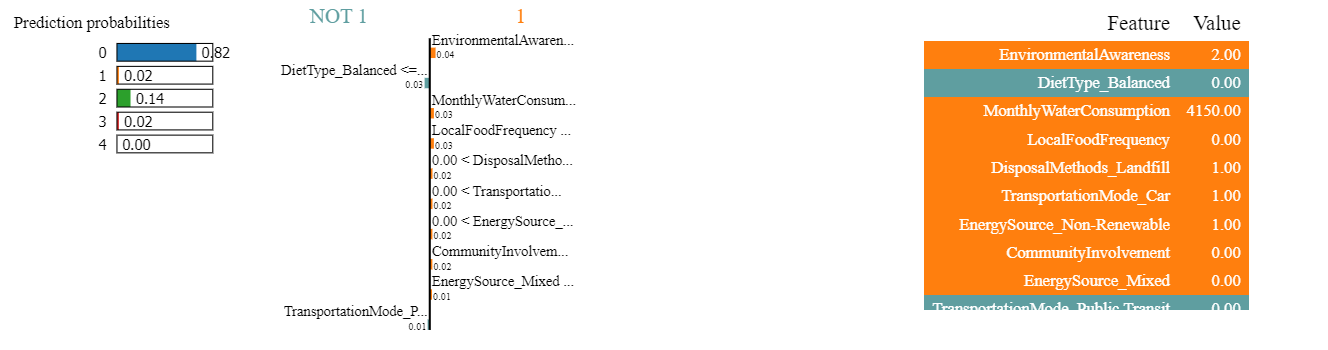

## Summary of key points:

- The target variable Rating is highly imbalanced
    - Due to small amount of data, synthesizing more data is prbably a good starting point (SMOTE)

- Gender-variable is slightly imbalanced, but can probably be adjusted by combining the more rare categories

- Due to huge amount of categorical variables, there are plenty of categorical combinations that do not exist in the data (Landfill, SustainableBrands, Male, for example)
    - This might be a deal-breaker for this dataset (from the point of view of training a good machine learning model)
    - Analyzing in more detail whether there are any crucial combinations missing, would be beneficial (combinations that should be in the data, but are not)
    - Synthetization techniques should be explored in order to mitigate this
    - Getting more and better data would be the best option (maybe combine with some other similar dataset?)
- Environmental awareness, Community involvement, local food frequency are related to highest rating, while animal based diet, using a car and low environmental awareness are related to lowest rating
    - animal based diets with low environmental awareness dominate ratings 1 and 2, balanced diet with average environmental awareness dominate the rating 3, and high environmental awareness with mostly plant based diets dominate ratings 4 and 5.
- Water consumption might be redundant, since it follows the same trend as electricity consumption
- Location can be probably be represented with a binary variable (rural/urban)
- HomeType house/apartment seem to have an effect, but HomeType other seems to affect nothing
    - This can be difficult to deal with, since we can't just remove the other types, since we would lose 20% of our data

___

In [1]:
# earlier notes on what to do with this report

# TODO:

# target and support variable distributions
# analyze imbalances and categorical combinations with too few examples in data (apriori results)
# compare trends, any contradictions towards the target variable?
# noise/overlap
# redundancy in variables (VIF-test + visualizations + others)
# outliers in the data (remember there's only 500 rows in this dataset)
# missing data, duplicates?
# ideas for combining and/or removing variables in this dataset?

# SHAP / LIME (used differently than in regression)